# Loan Default — Preprocessing Pipeline
Dataset: [nikhil1e9/loan-default](https://www.kaggle.com/datasets/nikhil1e9/loan-default)

| Column | Type | Description |
|---|---|---|
| LoanID | str | Unique identifier – will be dropped |
| Age | int | Borrower age |
| Income | float | Annual income (right-skewed → log transform) |
| LoanAmount | float | Requested loan amount (right-skewed → log transform) |
| CreditScore | int | Credit score 300–850 (strongest predictor, corr=−0.20) |
| MonthsEmployed | int | Months at current employer |
| NumCreditLines | int | Number of open credit lines |
| InterestRate | float | Loan interest rate % |
| LoanTerm | int | Loan duration in months |
| DTIRatio | float | Debt-to-income ratio (2nd strongest predictor) |
| Education | str | High School / Bachelor's / Master's / PhD → ordinal |
| EmploymentType | str | Full-time / Part-time / Self-employed / Unemployed → OHE |
| MaritalStatus | str | Single / Married / Divorced → OHE |
| HasMortgage | str | Yes / No → 1/0 |
| HasDependents | str | Yes / No → 1/0 |
| LoanPurpose | str | Home / Auto / Education / Business / Other → OHE |
| HasCoSigner | str | Yes / No → 1/0 |
| **Default** | int | **Target** – 1 = defaulted (~11.6%), 0 = not (~88.4%) |

> **Class imbalance**: 7.7:1 — addressed with SMOTETomek + class_weight in models

## 1 · Libraries

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2 · Load Raw Data

In [2]:
os.chdir("..")
df = pd.read_csv("data/raw/Loan_default.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (255347, 18)
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 3 · Class Imbalance Check
> **Critical first step** — understanding the imbalance guides every decision below.

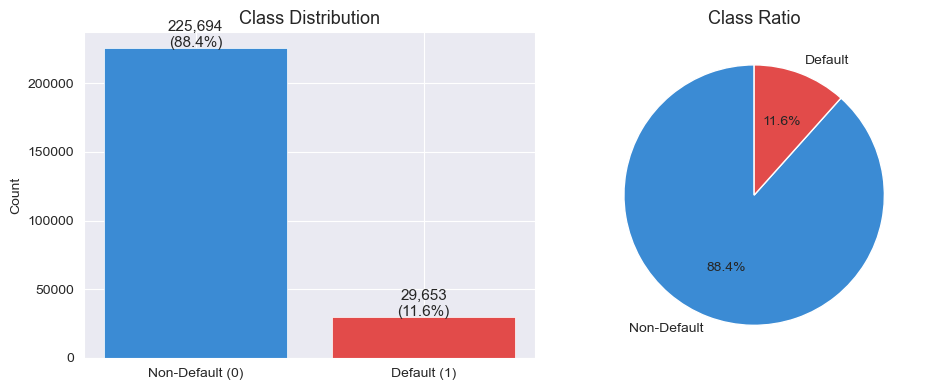


Imbalance ratio: 7.6:1
 Minority class (Default=1): 29,653 rows (11.61%)
 Strategy: SMOTETomek on training data only (no data leakage)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
target_counts = df['Default'].value_counts()
axes[0].bar(['Non-Default (0)', 'Default (1)'], target_counts.values, color=['#3B8BD4', '#E24B4A'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Pie
axes[1].pie(target_counts.values, labels=['Non-Default', 'Default'], colors=['#3B8BD4', '#E24B4A'], autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Class Ratio', fontsize=13)

plt.tight_layout()
plt.show()

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nImbalance ratio: {imbalance_ratio:.1f}:1")
print(f" Minority class (Default=1): {target_counts[1]:,} rows ({target_counts[1]/len(df)*100:.2f}%)")
print(f" Strategy: SMOTETomek on training data only (no data leakage)")

## 4 · Drop ID & Clean Column Names

In [4]:
df.drop(columns=['LoanID'], inplace=True)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns after cleaning:")
print(df.columns.tolist())

Columns after cleaning:
['age', 'income', 'loanamount', 'creditscore', 'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm', 'dtiratio', 'education', 'employmenttype', 'maritalstatus', 'hasmortgage', 'hasdependents', 'loanpurpose', 'hascosigner', 'default']


## 5 · Data Types & Binary Encoding

In [5]:
df.info()

# Yes/No → 1/0
binary_cols = ['hasmortgage', 'hasdependents', 'hascosigner']
df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'Yes': 1, 'No': 0}))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   age             255347 non-null  int64  
 1   income          255347 non-null  int64  
 2   loanamount      255347 non-null  int64  
 3   creditscore     255347 non-null  int64  
 4   monthsemployed  255347 non-null  int64  
 5   numcreditlines  255347 non-null  int64  
 6   interestrate    255347 non-null  float64
 7   loanterm        255347 non-null  int64  
 8   dtiratio        255347 non-null  float64
 9   education       255347 non-null  object 
 10  employmenttype  255347 non-null  object 
 11  maritalstatus   255347 non-null  object 
 12  hasmortgage     255347 non-null  object 
 13  hasdependents   255347 non-null  object 
 14  loanpurpose     255347 non-null  object 
 15  hascosigner     255347 non-null  object 
 16  default         255347 non-null  int64  
dtypes: float64

## 6 · Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]

if missing_df.empty:
    print("No missing values found")
else:
    print(missing_df)
    num_cols = df.select_dtypes(include='number').columns
    cat_cols = df.select_dtypes(include='object').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values imputed")

No missing values found


## 7 · Remove Duplicates

In [7]:
n_before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {n_before - len(df)} duplicates → shape: {df.shape}")

Removed 0 duplicates → shape: (255347, 17)


## 8 · Outlier Detection
Using **Isolation Forest ∩ LOF** (intersection = high-confidence outliers only)  
Applied on numeric features only (excluding target).

In [8]:
num_cols = df.select_dtypes(include='number').columns.drop('default', errors='ignore')
num_data = df[num_cols]

iso_mask = IsolationForest(contamination=0.05, random_state=42).fit_predict(num_data) == -1
lof_mask = LocalOutlierFactor(n_neighbors=30, contamination=0.05).fit_predict(num_data) == -1

outlier_mask    = iso_mask & lof_mask
outlier_indices = df.index[outlier_mask]
n_out           = outlier_mask.sum()
threshold       = int(0.05 * len(df))

print(f"Outliers found: {n_out}  |  5% threshold: {threshold}")
print(f"Outlier class distribution: {df.loc[outlier_mask, 'default'].value_counts().to_dict()}")

Outliers found: 872  |  5% threshold: 12767
Outlier class distribution: {0: 738, 1: 134}


In [9]:
if n_out == 0:
    print("No outliers found ")
elif n_out < threshold:
    df.drop(index=outlier_indices, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Dropped {n_out} rows → new shape: {df.shape}")
else:
    for col in num_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        lo, hi = Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1)
        df.loc[outlier_indices, col] = df.loc[outlier_indices, col].clip(lo, hi)
    print(f"Clipped {n_out} outlier rows  → shape: {df.shape}")

Dropped 872 rows → new shape: (254475, 17)


## 9 · Skewness Analysis & Log Transformation
Income and LoanAmount have skewness ~2.0 — log1p normalises the distribution  
and reduces the influence of extreme values on linear models.

In [10]:
num_features = ['income', 'loanamount', 'age', 'creditscore', 'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm', 'dtiratio']

skew_before = df[num_features].skew().round(3)
print("Skewness before transformation:")
print(skew_before.sort_values(ascending=False).to_string())

# Apply log1p to right-skewed features (skewness > 0.75)
log_cols = ['income', 'loanamount']
for col in log_cols:
    df[f'log_{col}'] = np.log1p(df[col])

print(f"\nLog1p applied to: {log_cols}")
print(f" income skew: {df['income'].skew():.2f} → {df['log_income'].skew():.2f}")
print(f" loanamount skew: {df['loanamount'].skew():.2f} → {df['log_loanamount'].skew():.2f}")

Skewness before transformation:
creditscore       0.005
interestrate      0.005
age               0.001
income           -0.000
numcreditlines    0.000
dtiratio         -0.001
loanamount       -0.002
monthsemployed   -0.002
loanterm         -0.002

Log1p applied to: ['income', 'loanamount']
 income skew: -0.00 → -0.78
 loanamount skew: -0.00 → -1.25


## 10 · Encode Categorical Features
- **Education**: ordinal (natural order exists)  
- **EmploymentType, MaritalStatus, LoanPurpose**: one-hot (no natural order)

In [11]:
# Ordinal: Education has a clear knowledge-level ordering
edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
df['education'] = df['education'].map({v: i for i, v in enumerate(edu_order)})

# One-Hot Encoding
df = pd.get_dummies(df, columns=['employmenttype', 'maritalstatus', 'loanpurpose'], drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Shape after encoding: (254475, 25)
Columns: ['age', 'income', 'loanamount', 'creditscore', 'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm', 'dtiratio', 'education', 'hasmortgage', 'hasdependents', 'hascosigner', 'default', 'log_income', 'log_loanamount', 'employmenttype_Part-time', 'employmenttype_Self-employed', 'employmenttype_Unemployed', 'maritalstatus_Married', 'maritalstatus_Single', 'loanpurpose_Business', 'loanpurpose_Education', 'loanpurpose_Home', 'loanpurpose_Other']


## 11 · Feature Engineering
**Philosophy**: build features that capture the *interaction* between risk factors.  
A borrower with high DTI AND low CreditScore AND high InterestRate is far more  
risky than any one factor alone — composite features let the model see this directly.

| Feature | Formula | Why |
|---|---|---|
| `loan_to_income` | LoanAmount / Income | Affordability ratio |
| `employment_ratio` | MonthsEmployed / (Age×12) | Job stability relative to age |
| `creditscore_band` | cut(CreditScore, [300,580,670,740,850]) | Non-linear risk tiers |
| `high_risk_flag` | DTI>0.45 AND CreditScore<600 | Known double-risk pattern |
| `monthly_payment_est` | LoanAmount × Rate / (Term×12) | Estimated monthly burden |
| `payment_to_income` | monthly_payment / (Income/12) | Real affordability pressure |
| `debt_burden_score` | DTIRatio × InterestRate | Combined debt stress index |
| `risk_score` | 0.4×(1−CS_norm) + 0.35×DTI + 0.25×Rate_norm | Composite risk signal |
| `log_loan_to_income` | log(LoanAmount) − log(Income) | Scale-robust version |
| `is_very_high_risk` | CS<580 AND DTI>0.4 AND Rate>15 | Triple-risk binary flag |
| `age_employment_interaction` | Age × MonthsEmployed | Maturity × stability |

In [12]:
# ── Original features (kept for compatibility) ──────────────────
df['loan_to_income']    = df['loanamount'] / (df['income'] + 1)
df['monthly_income']    = df['income'] / 12
df['employment_ratio']  = df['monthsemployed'] / (df['age'] * 12 + 1)
df['creditscore_band']  = pd.cut(df['creditscore'], bins=[0, 580, 670, 740, 850], labels=[0, 1, 2, 3]).astype(int)
df['high_risk_flag']    = ((df['dtiratio'] > 0.45) & (df['creditscore'] < 600)).astype(int)

# ── NEW: Interaction & composite features ───────────────────────
# Monthly payment estimate (simple approximation)
df['monthly_payment_est'] = (df['loanamount'] * df['interestrate'] / 100) / (df['loanterm'] + 1)

# Payment-to-income: real affordability pressure
df['payment_to_income'] = df['monthly_payment_est'] / (df['monthly_income'] + 1)

# Debt burden: DTI × Interest rate (stress index)
df['debt_burden_score'] = df['dtiratio'] * df['interestrate']

# Composite risk score (weighted combination of top predictors)
cs_norm   = (df['creditscore'] - 300) / 550      # 0 = worst, 1 = best
rate_norm = df['interestrate'] / 30               # 0 = lowest, 1 = highest
df['risk_score'] = (
    0.40 * (1 - cs_norm) +      # CreditScore (inverted — lower is riskier)
    0.35 * df['dtiratio'] +      # DTI ratio
    0.25 * rate_norm             # Interest rate
     )

# Log-scale loan-to-income (robust to outliers)
df['log_loan_to_income'] = df['log_loanamount'] - df['log_income']

# Triple-risk binary flag
df['is_very_high_risk'] = (
    (df['creditscore'] < 580) &
    (df['dtiratio']    > 0.40) &
    (df['interestrate'] > 15)
).astype(int)

# Age × employment stability
df['age_employment_interaction'] = df['age'] * df['monthsemployed']

print(f"Shape after feature engineering: {df.shape}")
print(f"\nNew features added:")
new_feats = ['monthly_payment_est','payment_to_income','debt_burden_score',
             'risk_score','log_loan_to_income','is_very_high_risk','age_employment_interaction']
print(df[new_feats].describe().round(3).to_string())

Shape after feature engineering: (254475, 37)

New features added:
       monthly_payment_est  payment_to_income  debt_burden_score  risk_score  log_loan_to_income  is_very_high_risk  age_employment_interaction
count           254475.000         254475.000         254475.000  254475.000          254475.000         254475.000                  254475.000
mean               620.614              0.127              6.749       0.488               0.336              0.136                    2589.599
std                684.347              0.196              4.802       0.151               1.013              0.343                    1825.529
min                  2.043              0.000              0.201       0.056              -3.388              0.000                       0.000
25%                170.163              0.026              2.833       0.378              -0.217              0.000                    1116.000
50%                396.833              0.063              5.535     

### 11.1 · Feature Correlation with Target (validation)

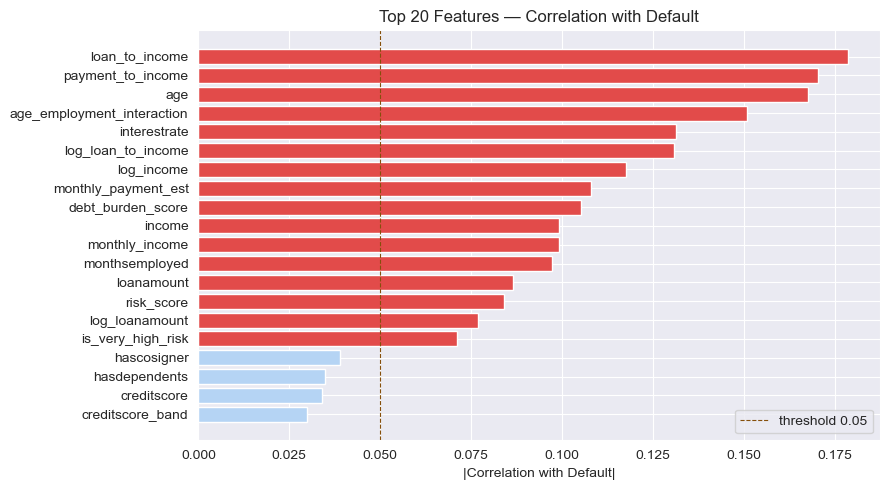


🔴 Features above 0.05 correlation threshold:
loan_to_income                0.178485
payment_to_income             0.170346
age                           0.167704
age_employment_interaction    0.150842
interestrate                  0.131199
log_loan_to_income            0.130737
log_income                    0.117608
monthly_payment_est           0.108053
debt_burden_score             0.105132
income                        0.099024
monthly_income                0.099024
monthsemployed                0.097218
loanamount                    0.086415
risk_score                    0.084059
log_loanamount                0.076900
is_very_high_risk             0.071068


In [14]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr()['default'].drop('default').abs().sort_values(ascending=False)
top_20 = correlations.head(20)

plt.figure(figsize=(9, 5))
colors = ['#E24B4A' if v > 0.05 else '#B5D4F4' for v in top_20.values]
plt.barh(top_20.index[::-1], top_20.values[::-1], color=colors[::-1])
plt.axvline(0.05, color='#854F0B', linestyle='--', linewidth=0.8, label='threshold 0.05')
plt.xlabel('|Correlation with Default|')
plt.title('Top 20 Features — Correlation with Default', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n🔴 Features above 0.05 correlation threshold:")
print(correlations[correlations > 0.05].to_string())

## 12 · Train / Validation / Test Split
Standard 70 / 15 / 15 split with **stratify** to preserve class balance in each set.  
The **validation set** is used for threshold tuning — the **test set** is touched only once.

In [15]:
X = df.drop(columns=['default'])
y = df['default']

print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(f"Class balance in full dataset:\n{y.value_counts(normalize=True).round(3).to_string()}")

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split( X, y, test_size=0.30, random_state=42, stratify=y)
# Second split: temp → 50/50 → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split( X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTrain: {X_train.shape}  | Default rate: {y_train.mean():.3f}")
print(f"Validation: {X_val.shape}    | Default rate: {y_val.mean():.3f}")
print(f"Test: {X_test.shape}   | Default rate: {y_test.mean():.3f}")

X shape: (254475, 36)  |  y shape: (254475,)
Class balance in full dataset:
default
0    0.884
1    0.116

Train: (178132, 36)  | Default rate: 0.116
Validation: (38171, 36)    | Default rate: 0.116
Test: (38172, 36)   | Default rate: 0.116


## 13 · Handle Class Imbalance — SMOTETomek
**SMOTETomek** = SMOTE (creates synthetic minority samples) + Tomek Links (removes borderline majority samples)  
→ Better decision boundary than SMOTE alone, less noise  
⚠️ Applied **only on training data** — validation and test sets untouched

In [16]:
print(f"Before SMOTETomek:")
print(f"  Train class distribution: {dict(pd.Series(y_train).value_counts().sort_index())}")

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print(f"\nAfter SMOTETomek:")
print(f" Train class distribution: {dict(pd.Series(y_train_res).value_counts().sort_index())}")
print(f" Train shape: {X_train_res.shape}")
print(f"\nValidation and Test sets NOT resampled (no data leakage)")

Before SMOTETomek:
  Train class distribution: {0: np.int64(157469), 1: np.int64(20663)}

After SMOTETomek:
 Train class distribution: {0: np.int64(152476), 1: np.int64(152476)}
 Train shape: (304952, 36)

Validation and Test sets NOT resampled (no data leakage)


## 14 · Scaling
StandardScaler **fit on training data only** → transform applied to val & test  
The fitted scaler is saved to `models/scaler.pkl` for use in deployment and real_customers notebook

In [17]:
feature_names = X_train.columns.tolist()

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=feature_names)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_names)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

print("✅ Scaling applied")
print(f" Train mean (should be ~0): {X_train_scaled.mean().abs().mean():.4f}")
print(f" Train std  (should be ~1): {X_train_scaled.std().mean():.4f}")
print(f" Val mean  (naturally off): {X_val_scaled.mean().abs().mean():.4f}")

✅ Scaling applied
 Train mean (should be ~0): 0.0000
 Train std  (should be ~1): 1.0000
 Val mean  (naturally off): 0.1495


## 15 · Save Processed Data & Artifacts
Saves:
- Processed full dataset (before split) → `data/processed/`  
- Train / Val / Test splits → `data/processed/`  
- Fitted scaler → `models/scaler.pkl`  
- Feature names list → `models/feature_names.pkl`

In [18]:
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Full processed dataset (without split — for EDA reference)
df.to_parquet('data/processed/data_processed.parquet', index=False)

# Train (resampled) / Val / Test splits
X_train_scaled.to_parquet('data/processed/X_train.parquet', index=False)
X_val_scaled.to_parquet( 'data/processed/X_val.parquet',   index=False)
X_test_scaled.to_parquet('data/processed/X_test.parquet',  index=False)

pd.Series(y_train_res, name='default').to_frame().to_parquet('data/processed/y_train.parquet', index=False)
pd.Series(y_val, name='default').to_frame().to_parquet('data/processed/y_val.parquet',   index=False)
pd.Series(y_test, name='default').to_frame().to_parquet('data/processed/y_test.parquet',  index=False)

# Scaler + feature names (critical for deployment — DO NOT refit on new data)
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')

print("All artifacts saved")
print(f"\nSummary:")
print(f"X_train (resampled): {X_train_scaled.shape}")
print(f"X_val: {X_val_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}")
print(f"Features: {len(feature_names)}")
print(f"Scaler: models/scaler.pkl")

All artifacts saved

Summary:
X_train (resampled): (304952, 36)
X_val: (38171, 36)
X_test: (38172, 36)
Features: 36
Scaler: models/scaler.pkl


## 16 · Preprocessing Summary

| Step | Action | Why |
|---|---|---|
| Drop LoanID | Removed identifier | No predictive value |
| Binary encoding | Yes/No → 1/0 | 3 columns |
| Missing values | None found | Dataset is clean |
| Duplicates | Removed | Data integrity |
| Outliers | Isolation Forest ∩ LOF → clip/drop | Robust detection |
| Log transform | Income, LoanAmount | Skewness ~2.0 → normalised |
| Ordinal encoding | Education | Natural order exists |
| One-Hot encoding | EmploymentType, MaritalStatus, LoanPurpose | No order |
| Feature engineering | 12 new features (5 original + 7 new) | Stronger signal |
| Train/Val/Test split | 70/15/15 stratified | Proper evaluation |
| SMOTETomek | Training only | Reduce imbalance without leakage |
| StandardScaler | Fit on train only | No leakage |
| Save scaler.pkl | Persisted to disk | Reuse in deployment |

**Key insight**: The raw features have weak correlations with Default (max −0.20).  
The composite features (risk_score, debt_burden_score, is_very_high_risk) concentrate  
the signal and are expected to be the top predictors in tree-based models.